In [22]:
from keras.layers import (Conv2D, MaxPooling2D, Input,
                          UpSampling2D, Conv2DTranspose)
from keras.models import Sequential
from keras.datasets import mnist
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [23]:
def create_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),

        Conv2D(16, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(8, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(4, (3, 3), padding='same', activation='relu'),

        UpSampling2D((2,2)),
        Conv2DTranspose(8, (3, 3), padding='same', activation='relu'),
        UpSampling2D((2,2)),
        Conv2DTranspose(16, (3, 3), padding='same', activation='relu'),

        Conv2D(1, (3, 3), padding='same', activation='sigmoid')
    ])
    model.compile(optimizer='Adam', loss='categorical_crossentropy')
    return model

In [24]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

In [25]:
autoencoder = create_model(input_shape=(28, 28, 1))
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()
autoencoder.fit(train_images, train_images,
                epochs = 2,
                batch_size=64
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 7, 7, 4)        │           292 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 14, 14, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 14, 14, 8)      │           296 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 28, 28, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,221 (12.58 KB)

 Trainable params: 3,221 (12.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.1323
Epoch 2/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - loss: 0.0824


In [26]:
autoencoder.save_weights('wagi.weights.h5')

In [27]:
encoder = create_model(input_shape=(28, 28, 1))
encoder.load_weights('wagi.weights.h5')

for _ in range(5):
    encoder.pop()

encoder.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 7, 7, 4)        │           292 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,612 (6.30 KB)

 Trainable params: 1,612 (6.30 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
result = encoder.predict(train_images)
a, b, c, d = result.shape

code = result.reshape(a, b*c*d)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(code, train_labels)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


KNeighborsClassifier()

In [30]:
encoded = encoder.predict(test_images)
a, b, c, d = encoded.shape
codes = encoded.reshape(a, b*c*d)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


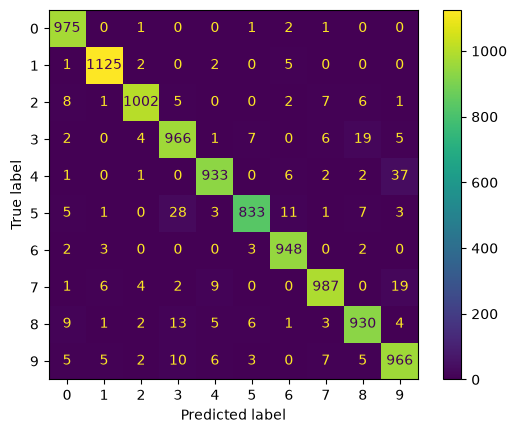

In [31]:
predictions = knn.predict(codes)
cm = confusion_matrix(test_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()